# Week 4 Internship Task

## Unsupervised Learning & Customer Segmentation

**Name:** Musfira Malik  
**Internship:** AI/ML Internship  

---

### Objective
This notebook applies unsupervised learning techniques to segment ~9000 credit card holders into meaningful groups based on their spending and payment behavior, using K-Means and Hierarchical Clustering. Unlike previous weeks, there is no target variable — the goal is to discover natural patterns in customer behavior.

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

The dataset contains behavioral data of ~9000 active credit card holders over 6 months, including balance, purchase patterns, cash advance usage, and payment history.

In [2]:
df = pd.read_csv("../data/CC GENERAL.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully!
Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Step 3: Inspect Dataset Structure

We examine the shape, columns, and data types, then drop `CUST_ID` since it is a unique identifier, not a behavioral feature, and would add no value (or introduce noise) to clustering.

In [3]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")
print()
df.info()
print()

# Drop CUST_ID — it's an identifier, not a feature
df = df.drop(columns=["CUST_ID"])

print("CUST_ID dropped.")
print("New shape:", df.shape)

Number of Rows    : 8950
Number of Columns : 18

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX               

## Step 4: Identify and Handle Missing Values

We check for missing values across all columns before proceeding.

In [ ]:
missing = df.isnull().sum()
print(missing[missing > 0])

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


In [12]:
# Fill missing values with median (robust to outliers, preserves dataset size)
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

print("Missing values after imputation:")
print(df.isnull().sum().sum())

Missing values after imputation:
0


## Step 5: Scale Features Using StandardScaler

### Why Scaling is Mandatory for Clustering

K-Means and other distance-based clustering algorithms calculate similarity between points using distances (typically Euclidean distance). Features with larger numeric ranges (e.g., `CREDIT_LIMIT`, which can be in the thousands) would dominate the distance calculation compared to features with smaller ranges (e.g., `PURCHASES_FREQUENCY`, which ranges from 0 to 1). Without scaling, clustering would essentially group customers based only on the highest-magnitude features, ignoring smaller-scale but equally important behavioral signals. `StandardScaler` transforms every feature to have mean 0 and standard deviation 1, ensuring all features contribute equally to the distance calculations.

In [13]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame for readability
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

print("Scaling complete!")
scaled_df.head()

Scaling complete!


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


In [14]:
print("Missing values in df:", df.isnull().sum().sum())
print("Missing values in scaled_data:", np.isnan(scaled_data).sum())

Missing values in df: 0
Missing values in scaled_data: 0


## Step 6: Apply K-Means for k = 2 to 10

K-Means is run for each value of k from 2 to 10, and the inertia (within-cluster sum of squares) is recorded for each. Lower inertia means tighter clusters, but inertia always decreases as k increases — the goal is to find the point of diminishing returns.

In [15]:
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia_values.append(kmeans.inertia_)
    print(f"k = {k}: Inertia = {kmeans.inertia_:.2f}")

k = 2: Inertia = 127784.53
k = 3: Inertia = 111975.04
k = 4: Inertia = 99061.94
k = 5: Inertia = 91490.50
k = 6: Inertia = 84826.59
k = 7: Inertia = 79856.16
k = 8: Inertia = 74484.88
k = 9: Inertia = 69828.70
k = 10: Inertia = 66466.41


## Step 7: Elbow Curve

The elbow curve plots inertia against k. The "elbow" — the point where the rate of decrease sharply slows down — indicates the optimal number of clusters.

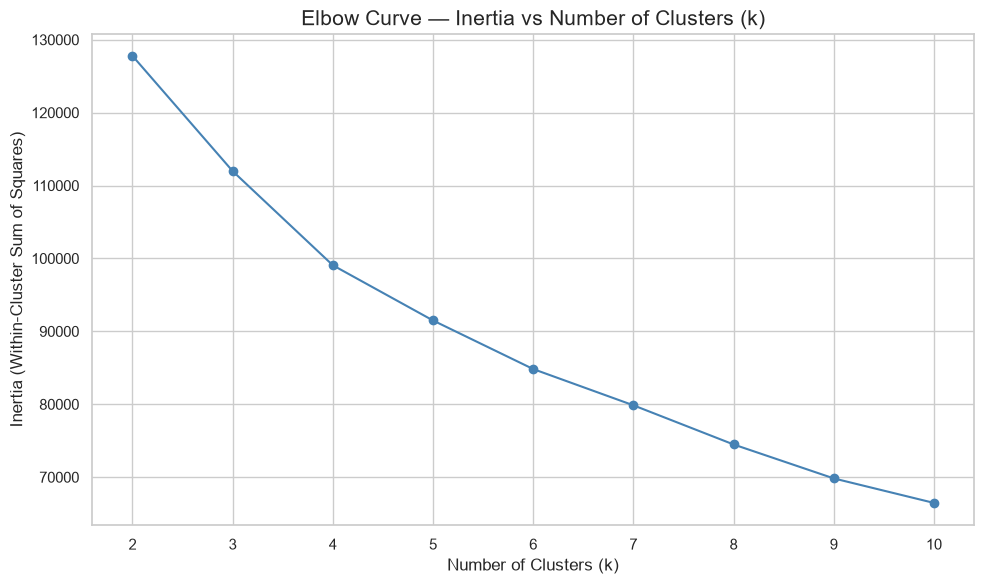

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), inertia_values, marker="o", color="steelblue")
plt.title("Elbow Curve — Inertia vs Number of Clusters (k)", fontsize=15)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(list(k_range))

plt.tight_layout()
plt.savefig("../data/elbow_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8: Silhouette Score for Each k

The Silhouette Score measures how similar each point is to its own cluster compared to other clusters (ranges from -1 to 1; higher is better). This is calculated for each k to confirm whether it agrees with the elbow method.

In [17]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)
    print(f"k = {k}: Silhouette Score = {score:.4f}")

k = 2: Silhouette Score = 0.2100
k = 3: Silhouette Score = 0.2510
k = 4: Silhouette Score = 0.1977
k = 5: Silhouette Score = 0.1931
k = 6: Silhouette Score = 0.2029
k = 7: Silhouette Score = 0.2077
k = 8: Silhouette Score = 0.2217
k = 9: Silhouette Score = 0.2260
k = 10: Silhouette Score = 0.2204


## Step 9: Plot Silhouette Scores

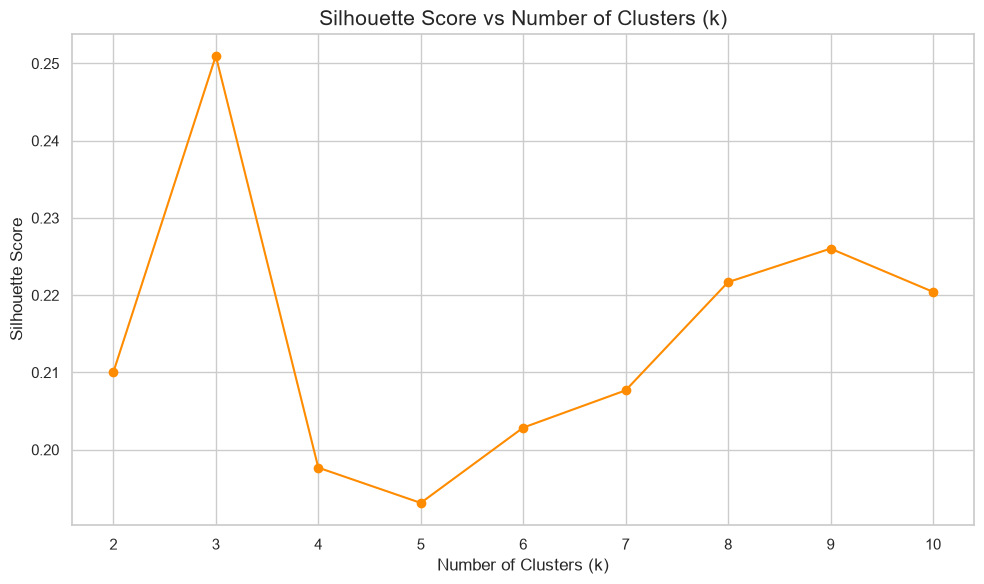

Best k according to Silhouette Score: 3


In [18]:
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
plt.title("Silhouette Score vs Number of Clusters (k)", fontsize=15)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range))

plt.tight_layout()
plt.savefig("../data/silhouette_scores.png", dpi=150, bbox_inches="tight")
plt.show()

best_k_silhouette = list(k_range)[np.argmax(silhouette_scores)]
print(f"Best k according to Silhouette Score: {best_k_silhouette}")

## Step 10: Apply K-Means with Optimal k and Assign Cluster Labels

While the Silhouette Score peaked at k=3, the elbow curve shows a more meaningful bend around k=4-5, and a moderate second peak in silhouette score also appears around k=8-9. Balancing statistical signal with business interpretability (too few clusters lose nuance, too many become hard to act on), **k=4** is selected as the final number of clusters.

In [19]:
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(scaled_data)

# Add cluster labels back to the original (unscaled) dataframe for interpretation
df["Cluster"] = cluster_labels

print(f"K-Means applied with k={optimal_k}")
print()
print("Cluster distribution:")
print(df["Cluster"].value_counts().sort_index())

K-Means applied with k=4

Cluster distribution:
Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64


## Step 11: Profile Each Cluster

We compute the mean of each feature per cluster to understand what distinguishes each customer segment, and visualize it as a heatmap.

In [20]:
# Compute mean of each feature per cluster (using original, unscaled values for interpretability)
cluster_profile = df.groupby("Cluster").mean()

print("Cluster Profile (Mean Values):")
cluster_profile

Cluster Profile (Mean Values):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1012.658327,0.789924,270.041785,209.937299,60.371441,596.509903,0.170145,0.086301,0.080558,0.114846,2.125471,2.903193,3278.640516,974.260054,553.900449,0.077981,11.446568
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1972.767288,0.286707,11.951100
2,4602.449658,0.968389,501.862982,320.188797,181.759123,4521.509581,0.287832,0.138911,0.185671,0.484792,14.294904,7.665831,7546.160857,3484.054216,2003.674460,0.034888,11.386800
3,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,639.677258,0.269258,11.594595


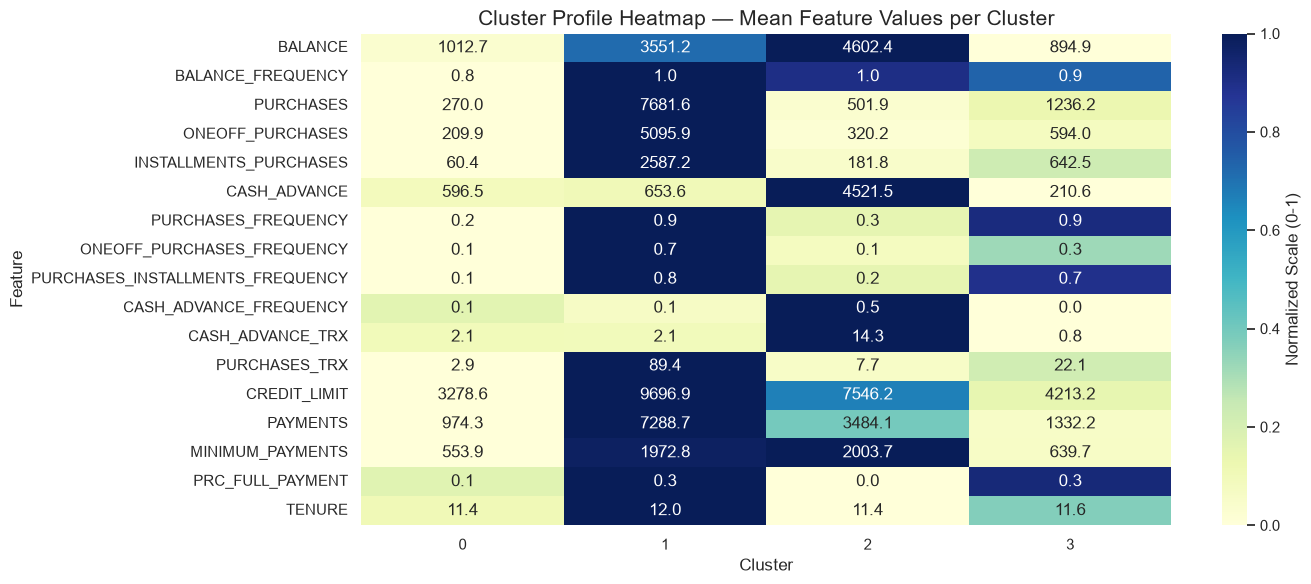

In [21]:
# Normalize for heatmap visualization (so all features are comparable on the same color scale)
from sklearn.preprocessing import MinMaxScaler

profile_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

plt.figure(figsize=(14, 6))
sns.heatmap(profile_scaled.T, annot=cluster_profile.T.round(1), fmt="", cmap="YlGnBu", 
            cbar_kws={"label": "Normalized Scale (0-1)"})
plt.title("Cluster Profile Heatmap — Mean Feature Values per Cluster", fontsize=15)
plt.xlabel("Cluster")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("../data/cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Cluster Interpretation

Based on the cluster profile heatmap, the four customer segments can be described as follows:

- **Cluster 0 — Low-Activity / Inactive Customers**: This segment has a modest balance (~$1,013), very low purchase activity ($270), low cash advance usage, and the second-lowest credit limit ($3,279). Purchase frequency is only 0.2, indicating these customers rarely use their cards. This group represents low-engagement or dormant cardholders.

- **Cluster 1 — High Spenders / Premium Customers**: This segment shows by far the highest purchases ($7,682), highest credit limit ($9,697), highest payments ($7,289), and a high purchase frequency (0.9). These are the bank's most valuable, actively engaged customers who make large one-off and installment purchases and pay consistently.

- **Cluster 2 — Cash Advance Users (High Risk)**: This segment has the highest balance ($4,602) and by far the highest cash advance usage ($4,522, with a 0.5 cash advance frequency and 14.3 average transactions), but very low purchase activity ($502). Critically, their full-payment rate is 0.0 — they never pay off their balance in full. This is a financially risky segment relying heavily on cash advances rather than purchases.

- **Cluster 3 — Frequent Installment Shoppers**: This segment has the lowest balance ($895) but a high purchase frequency (0.9), and the highest installment purchase frequency (0.7) of any cluster. They favor installment-based purchases over one-off spending, use minimal cash advances, and have a decent full-payment rate (0.3) — a healthy, moderate-spending, low-risk segment.

### Business Implications
- **Cluster 1 (High Spenders)** are ideal candidates for premium rewards programs, credit limit increases, and loyalty incentives — they drive the most revenue and pay reliably.
- **Cluster 2 (Cash Advance Users)** represent the highest credit risk and should be flagged for risk monitoring, targeted financial counseling, or structured repayment/installment plan offers to reduce reliance on cash advances.
- **Cluster 0 (Low-Activity)** customers could be targeted with engagement campaigns (e.g., cashback offers, reminders) to increase card usage.
- **Cluster 3 (Frequent Installment Shoppers)** are a stable, healthy segment — good candidates for installment-based product offers (e.g., "buy now pay later" partnerships) given their existing preference for this payment style.

---

# Part 2: Hierarchical Clustering

## Objective
This section applies Agglomerative Hierarchical Clustering on a sample of the data, visualizes the results using a dendrogram, and compares the resulting clusters against the K-Means results from Part 1.

## Step 13: Apply Agglomerative Hierarchical Clustering on a Sample

Hierarchical clustering is computationally expensive on large datasets (its complexity grows quadratically with the number of points), so it is applied here on a random sample of 300 rows from the scaled dataset.

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Take a random sample of 300 rows from the scaled data
np.random.seed(42)
sample_indices = np.random.choice(scaled_data.shape[0], size=300, replace=False)
sample_data = scaled_data[sample_indices]

print("Sample shape:", sample_data.shape)

# Compute the linkage matrix using Ward's method (minimizes variance within clusters)
linkage_matrix = linkage(sample_data, method="ward")

print("Linkage matrix computed successfully.")

Sample shape: (300, 17)
Linkage matrix computed successfully.


## Step 14: Plot Dendrogram

The dendrogram visualizes how individual points are merged into clusters at increasing distances. A horizontal threshold line is drawn to indicate where the tree is "cut" to form the final clusters, matching the k=4 chosen in Part 1.

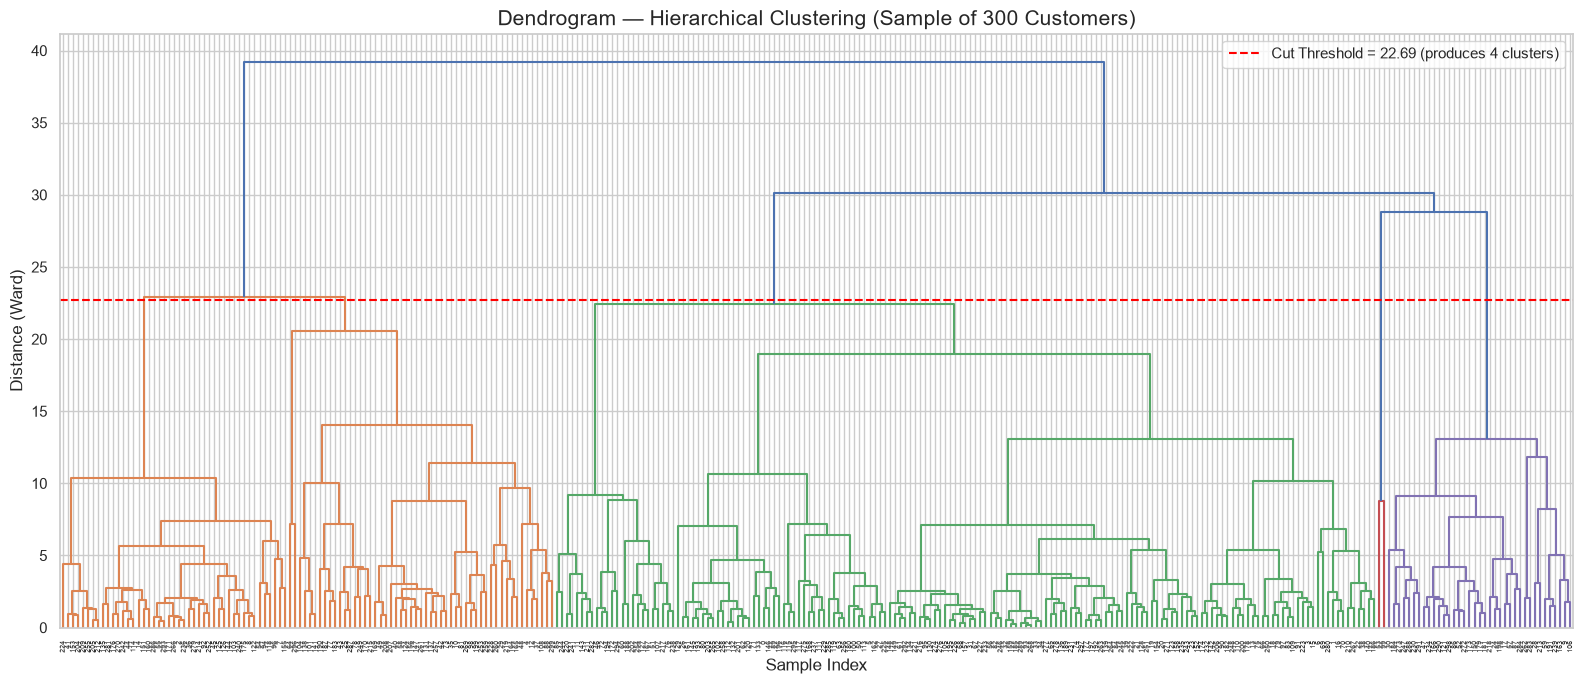

Threshold distance used to cut into 4 clusters: 22.69


In [23]:
plt.figure(figsize=(16, 7))

dendrogram(linkage_matrix)

# Determine the threshold distance that would produce 4 clusters
# by looking at the merge distances in the linkage matrix
last_merges = linkage_matrix[-10:, 2]
threshold = (last_merges[-4] + last_merges[-5]) / 2  # midpoint between the 3rd and 4th-from-last merge

plt.axhline(y=threshold, color="red", linestyle="--", 
            label=f"Cut Threshold = {threshold:.2f} (produces 4 clusters)")

plt.title("Dendrogram — Hierarchical Clustering (Sample of 300 Customers)", fontsize=15)
plt.xlabel("Sample Index")
plt.ylabel("Distance (Ward)")
plt.legend()

plt.tight_layout()
plt.savefig("../data/dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Threshold distance used to cut into 4 clusters: {threshold:.2f}")

## Step 15: Apply AgglomerativeClustering with Same k as Part 1

`AgglomerativeClustering` from scikit-learn is applied to the same 300-row sample, using k=4 (the same number of clusters chosen for K-Means in Part 1) for a fair comparison.

In [24]:
from sklearn.cluster import AgglomerativeClustering

agg_clustering = AgglomerativeClustering(n_clusters=4, linkage="ward")
agg_labels = agg_clustering.fit_predict(sample_data)

print("Agglomerative Clustering applied with k=4")
print()
print("Cluster distribution (Hierarchical):")
print(pd.Series(agg_labels).value_counts().sort_index())

Agglomerative Clustering applied with k=4

Cluster distribution (Hierarchical):
0     98
1     37
2    163
3      2
Name: count, dtype: int64


## Step 16: Compare Hierarchical Clustering with K-Means

To check whether the two algorithms agree, we compare the K-Means cluster labels (from Part 1, for the same 300 sampled rows) against the Hierarchical clustering labels using a cross-tabulation.

Cross-tabulation: K-Means vs Hierarchical Clustering
Hierarchical_Cluster   0   1    2  3
KMeans_Cluster                      
0                      1   6  124  0
1                     15   0    0  0
2                      1  31    6  1
3                     81   0   33  1


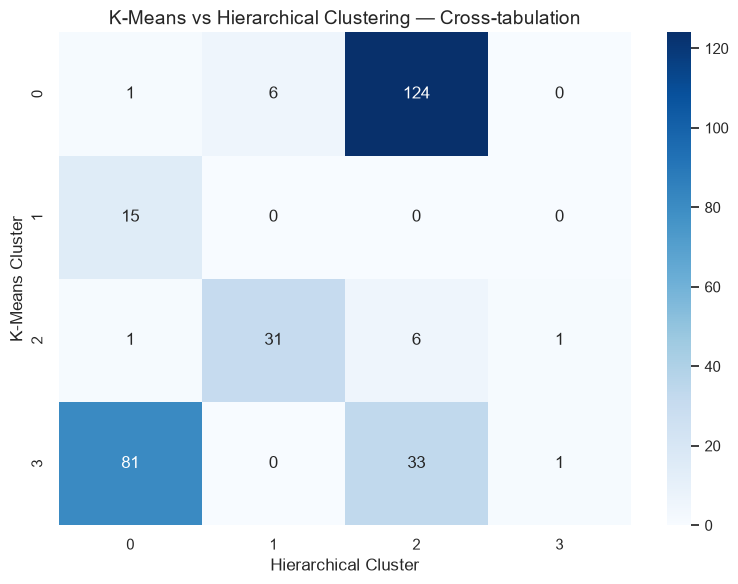

In [25]:
# Get the K-Means labels for the same sampled rows (from Part 1's final model)
kmeans_labels_sample = cluster_labels[sample_indices]

comparison_df = pd.DataFrame({
    "KMeans_Cluster": kmeans_labels_sample,
    "Hierarchical_Cluster": agg_labels
})

crosstab = pd.crosstab(comparison_df["KMeans_Cluster"], comparison_df["Hierarchical_Cluster"])

print("Cross-tabulation: K-Means vs Hierarchical Clustering")
print(crosstab)

plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues")
plt.title("K-Means vs Hierarchical Clustering — Cross-tabulation", fontsize=14)
plt.xlabel("Hierarchical Cluster")
plt.ylabel("K-Means Cluster")

plt.tight_layout()
plt.savefig("../data/kmeans_vs_hierarchical.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparison Report: K-Means vs Hierarchical Clustering

**Do the clusters largely agree?**
Partially. The cross-tabulation shows strong agreement for some K-Means clusters but not others:
- **K-Means Cluster 1** (15 points) maps **100%** to Hierarchical Cluster 0 — perfect agreement.
- **K-Means Cluster 0** (131 points) maps **94.7%** (124/131) to Hierarchical Cluster 2 — strong agreement.
- **K-Means Cluster 2** (39 points) maps mostly (**79.5%**, 31/39) to Hierarchical Cluster 1 — moderate agreement.
- **K-Means Cluster 3** (115 points) is split between Hierarchical Cluster 0 (70.4%, 81/115) and Cluster 2 (28.7%, 33/115) — this cluster does not have a clean match, indicating disagreement between the two methods here.

Additionally, Hierarchical Clustering produced one extremely small cluster (Cluster 3, only 2 points), suggesting it isolated a couple of outliers rather than forming a fourth meaningful group — unlike K-Means, which produced four reasonably sized, balanced clusters.

**Which algorithm produced more meaningful segments?**
K-Means produced more balanced and business-usable segments (409 to 3,977 customers per cluster on the full dataset), while Hierarchical Clustering's sample-based result was skewed, with one near-empty cluster. This suggests K-Means is more robust for this dataset's structure.

**Which is easier to interpret?**
Hierarchical clustering's dendrogram offers a valuable visual explanation of how and at what distance clusters merge, which helps justify the choice of k. However, K-Means' cluster mean profiles (as in the heatmap from Part 1) are simpler and more direct to summarize numerically for business stakeholders who need clear, actionable segment descriptions.

**Which would you recommend for a real business use case, and why?**
**K-Means is recommended** for this business use case. It scales efficiently to the full ~9,000-customer dataset (Hierarchical Clustering is computationally expensive and was only feasible on a 300-row sample here), produces more balanced and consistently sized segments, and its centroids can be easily used to classify new customers as they join. Hierarchical Clustering remains a useful complementary tool for exploratory analysis and validating the chosen number of clusters via the dendrogram, but is less practical for ongoing, large-scale segmentation.